## Problem Statement
The goal of this project is to predict house prices using multiple housing features such as area, number of rooms, and other attributes using Linear Regression.

# Importing Required Libraries

In [2]:
#packages for data reading and manipulating
import pandas as pd
import numpy as np
import openpyxl as oxl

#packages for data visualization
import matplotlib as mlt
import matplotlib.pyplot as plt
import seaborn as sns

#machine-learning libraries
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error

## Dataset Description
The dataset contains housing-related features and the target variable 'medv' representing median house price.

### General Information about Dataset

- CRIM per capita crime rate by town
- ZN proportion of residential land zoned for lots over 25,000 sq.ft.
- INDUS proportion of non-retail business acres per town
- CHAS Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
- NOX nitric oxides concentration (parts per 10 million)
- RM average number of rooms per dwelling
- AGE proportion of owner-occupied units built prior to 1940
- DIS weighted distances to five Boston employment centres
- RAD index of accessibility to radial highways
- TAX full-value property-tax rate per 10,000usd
- PTRATIO pupil-teacher ratio by town
- B 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
- LSTAT % lower status of the population

In [4]:
#reading the .csv file (comma separated values)
df = pd.read_csv('boston.csv',sep = ",")
print("File read successfull --")
print("Displaying the content of the file --")
df

File read successfull --
Displaying the content of the file --


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


## Exploratory Data Analysis (EDA)

We analyze data distribution, relationships, and detect outliers to better understand feature behavior before modeling.

In [6]:
#display first 5 rows
df.head()
#to display first n rows
#df.head(n)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [5]:
#display last 5 rows
df.tail()
#to display last n rows
#df.tail(n)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273,21.0,396.90,7.88,11.9


In [7]:
#to display an sample row
df.sample()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
289,0.04297,52.5,5.32,0,0.405,6.565,22.9,7.3172,6,293,16.6,371.72,9.51,24.8


In [8]:
#to display n sample from the dataset
df.sample(3)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
260,0.54011,20.0,3.97,0,0.647,7.203,81.8,2.1121,5,264,13.0,392.80,9.59,33.8
353,0.01709,90.0,2.02,0,0.410,6.728,36.1,12.1265,5,187,17.0,384.46,4.50,30.1
248,0.16439,22.0,5.86,0,0.431,6.433,49.1,7.8265,7,330,19.1,374.71,9.52,24.5


In [9]:
#display shape of the dataset
#that is total columns and rows
df.shape

(506, 14)

In [10]:
#display all columns
df.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'black', 'lstat', 'medv'],
      dtype='object')

In [11]:
#basic information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  black    506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [12]:
#to get datatype of each column
df.dtypes

crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
black      float64
lstat      float64
medv       float64
dtype: object

In [13]:
#statistical data about our dataset
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### Data Cleaning


- Check for Null Values
- Check for Duplicates Values/Rows
- Check for outliers

In [16]:
#check for null values in dataset
#check for missing values
df.isnull()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,False,False,False,False,False,False,False,False,False,False,False,False,False,False
502,False,False,False,False,False,False,False,False,False,False,False,False,False,False
503,False,False,False,False,False,False,False,False,False,False,False,False,False,False
504,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [17]:
#sum of null values column-wise
df.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
black      0
lstat      0
medv       0
dtype: int64

In [18]:
#total count of null values in the dataset
df.isnull().sum().sum()

np.int64(0)

In [19]:
#check for duplicate rows
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
501    False
502    False
503    False
504    False
505    False
Length: 506, dtype: bool

In [20]:
#sum of duplicated rows in the dataset
df.duplicated().sum()

np.int64(0)

# Data Visualization

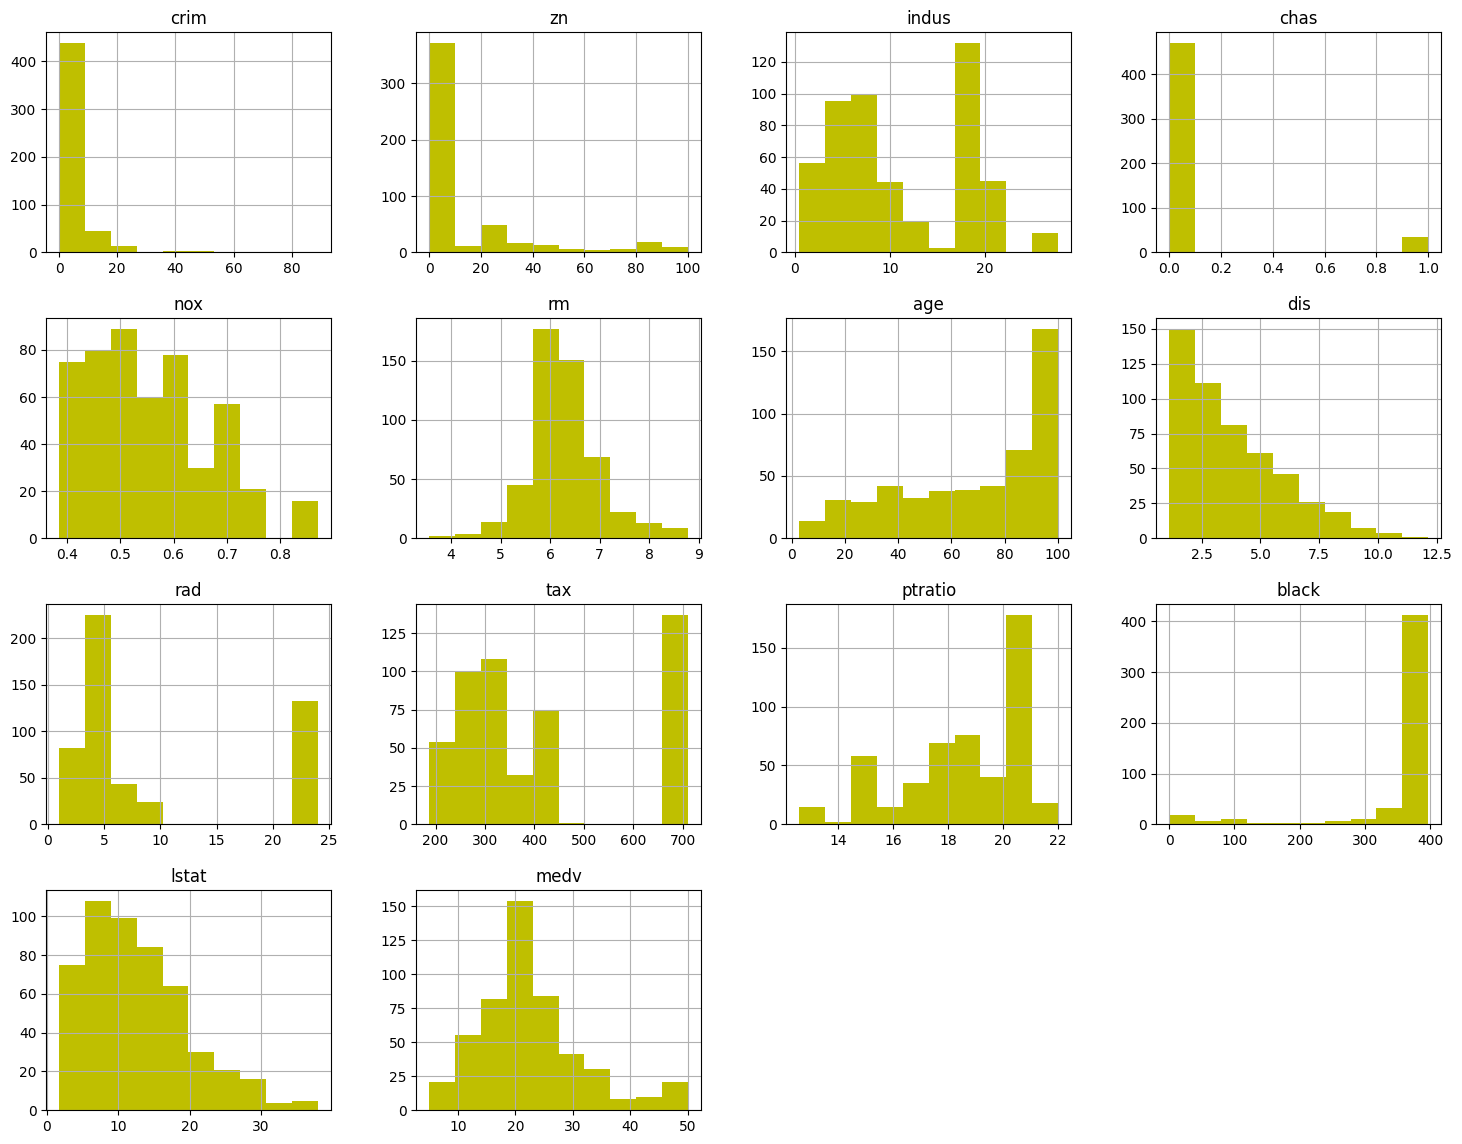

In [22]:
#Histogram
#distribution of all features
df.hist(figsize=(18,14),color = "y")
plt.show()

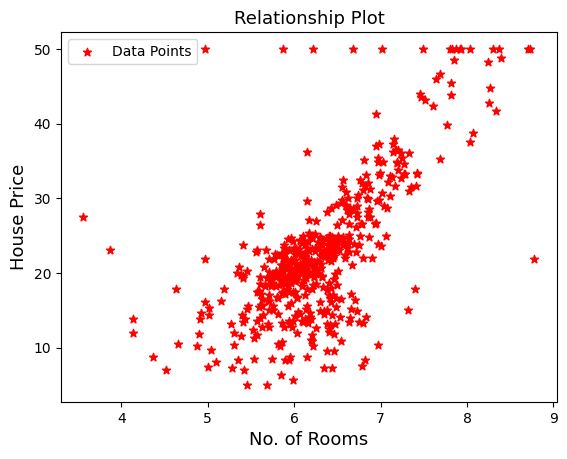

In [24]:
#Relationship between number of rooms and house price
#plotting an scatter plot
x = df['rm']
y = df['medv']
plt.scatter(x,y,color = "r",marker = "*",label = "Data Points")
plt.xlabel('No. of Rooms',fontsize = "13")
plt.ylabel('House Price',fontsize = "13")
plt.title("Relationship Plot",fontsize = "13")
plt.legend()
plt.show()

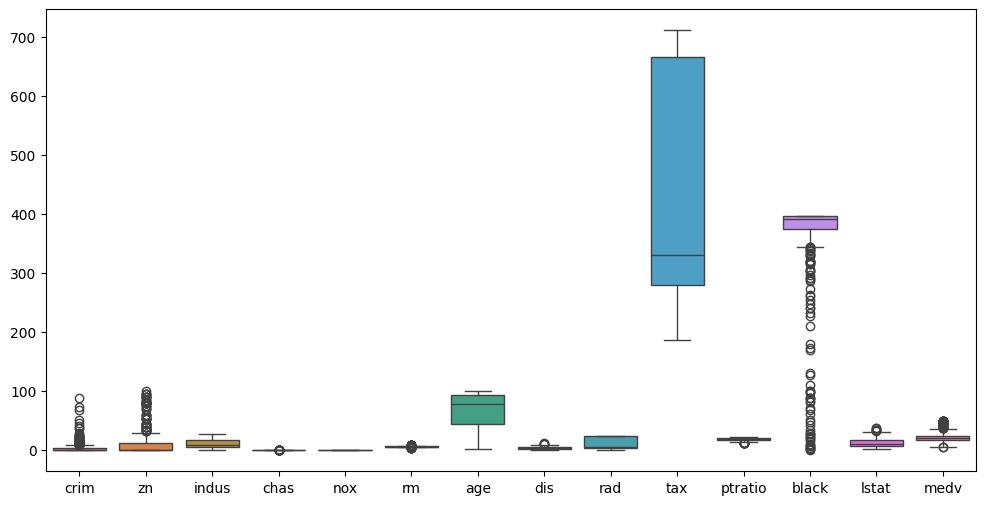

In [27]:
#Check for outlier using box-plot
#Box-Plot is for Outlier Detection
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation = 0)
#plt.legend()
plt.show()

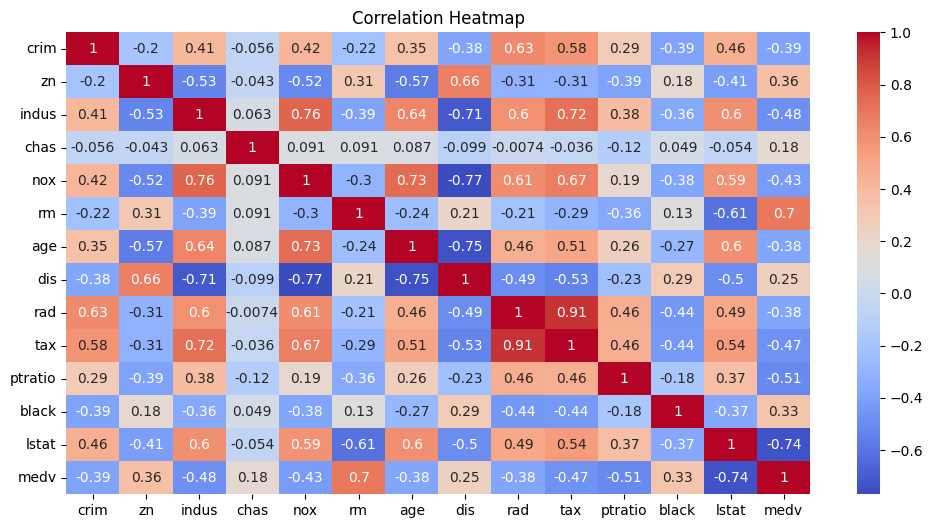

In [28]:
# Correlation between features

plt.figure(figsize=(12,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Feature Selection

In [29]:
#Separate festures (X) and target (y)
#X = Independent Variables/ Input Columns
#y = Dependent Variable/Target Column

X = df.drop(columns = 'medv')
y = df['medv']

In [30]:
#List of Input Columns/Independent Variables
X.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'black', 'lstat'],
      dtype='object')

In [31]:
#top 5 rows of input columns
X.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33


In [32]:
#top 5 rows of target columns
y.head()

0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: medv, dtype: float64

# Train-Test-Split

In [33]:
#Split the data into training and testing data
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [34]:
#first 5 rows of input training data
X_train.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat
477,15.02340,0.0,18.10,0,0.6140,5.304,97.3,2.1007,24,666,20.2,349.48,24.91
15,0.62739,0.0,8.14,0,0.5380,5.834,56.5,4.4986,4,307,21.0,395.62,8.47
332,0.03466,35.0,6.06,0,0.4379,6.031,23.3,6.6407,1,304,16.9,362.25,7.83
423,7.05042,0.0,18.10,0,0.6140,6.103,85.1,2.0218,24,666,20.2,2.52,23.29
19,0.72580,0.0,8.14,0,0.5380,5.727,69.5,3.7965,4,307,21.0,390.95,11.28


In [35]:
#first 5 rows of input testing data
X_test.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat
173,0.09178,0.0,4.05,0,0.510,6.416,84.1,2.6463,5,296,16.6,395.50,9.04
274,0.05644,40.0,6.41,1,0.447,6.758,32.9,4.0776,4,254,17.6,396.90,3.53
491,0.10574,0.0,27.74,0,0.609,5.983,98.8,1.8681,4,711,20.1,390.11,18.07
72,0.09164,0.0,10.81,0,0.413,6.065,7.8,5.2873,4,305,19.2,390.91,5.52
452,5.09017,0.0,18.10,0,0.713,6.297,91.8,2.3682,24,666,20.2,385.09,17.27


In [36]:
#first 5 rows of output/target training data
y_train.head()

477    12.0
15     19.9
332    19.4
423    13.4
19     18.2
Name: medv, dtype: float64

In [37]:
#first 5 rows of output/target testing data
y_test.head()

173    23.6
274    32.4
491    13.6
72     22.8
452    16.1
Name: medv, dtype: float64

# Model Training

In [38]:
#training the data by passing the training data (X_train,y_train)
model = LinearRegression()
model.fit(X_train,y_train)
#here our model is trained and our best-fit line is ready

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


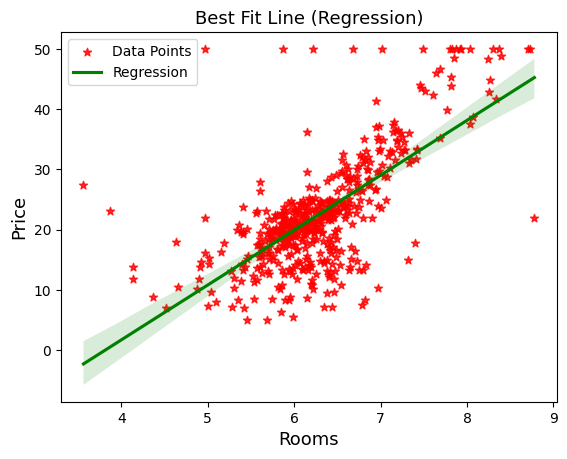

In [39]:
#line of Best-Fit Visualization
xx = df['rm']
yy = df['medv']

# Explicitly define x and y
sns.regplot(x=xx, y=yy, marker="*", color="r",line_kws={"color": "green","label":"Regression"},label = "Data Points")

plt.xlabel("Rooms",fontsize = 13)
plt.ylabel("Price",fontsize = 13)
plt.title("Best Fit Line (Regression)",fontsize = 13)
plt.legend()
plt.show()

In [40]:
model.coef_
#here are the values of w's from w1 to w13
#the eqn of the line becomes y = w1x1 + w2x2 + w3x3 + .....+ w13x13 + c

array([-1.13055924e-01,  3.01104641e-02,  4.03807204e-02,  2.78443820e+00,
       -1.72026334e+01,  4.43883520e+00, -6.29636221e-03, -1.44786537e+00,
        2.62429736e-01, -1.06467863e-02, -9.15456240e-01,  1.23513347e-02,
       -5.08571424e-01])

In [41]:
model.intercept_
#here is the value of intercept that is c

np.float64(30.24675099392349)

# Equation of Best Fit Regression line

In [43]:
# Display coefficients along with respective features
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coeff_df)
print("\nIntercept:", model.intercept_)

    Feature  Coefficient
0      crim    -0.113056
1        zn     0.030110
2     indus     0.040381
3      chas     2.784438
4       nox   -17.202633
5        rm     4.438835
6       age    -0.006296
7       dis    -1.447865
8       rad     0.262430
9       tax    -0.010647
10  ptratio    -0.915456
11    black     0.012351
12    lstat    -0.508571

Intercept: 30.24675099392349


In [46]:
eq = f"y = {model.intercept_:.2f}"

for coef, col in zip(model.coef_, X.columns):
    eq += f" + ({coef:.2f} * {col})"

print("The equation of the best file lines is as follows :- \n")
print(eq)

The equation of the best file lines is as follows :- 

y = 30.25 + (-0.11 * crim) + (0.03 * zn) + (0.04 * indus) + (2.78 * chas) + (-17.20 * nox) + (4.44 * rm) + (-0.01 * age) + (-1.45 * dis) + (0.26 * rad) + (-0.01 * tax) + (-0.92 * ptratio) + (0.01 * black) + (-0.51 * lstat)


# Prediction
### Comparision of Actual and Predicted

In [48]:
y_pred = model.predict(X_test)
y_pred

array([28.99672362, 36.02556534, 14.81694405, 25.03197915, 18.76987992,
       23.25442929, 17.66253818, 14.34119   , 23.01320703, 20.63245597,
       24.90850512, 18.63883645, -6.08842184, 21.75834668, 19.23922576,
       26.19319733, 20.64773313,  5.79472718, 40.50033966, 17.61289074,
       27.24909479, 30.06625441, 11.34179277, 24.16077616, 17.86058499,
       15.83609765, 22.78148106, 14.57704449, 22.43626052, 19.19631835,
       22.43383455, 25.21979081, 25.93909562, 17.70162434, 16.76911711,
       16.95125411, 31.23340153, 20.13246729, 23.76579011, 24.6322925 ,
       13.94204955, 32.25576301, 42.67251161, 17.32745046, 27.27618614,
       16.99310991, 14.07009109, 25.90341861, 20.29485982, 29.95339638,
       21.28860173, 34.34451856, 16.04739105, 26.22562412, 39.53939798,
       22.57950697, 18.84531367, 32.72531661, 25.0673037 , 12.88628956,
       22.68221908, 30.48287757, 31.52626806, 15.90148607, 20.22094826,
       16.71089812, 20.52384893, 25.96356264, 30.61607978, 11.59

In [49]:
y_pred.shape

(102,)

In [50]:
#how much our predictions are close to actual prices
results = pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
results.head()
#displaying first 5 rows

,Actual,Predicted
173,23.6,28.996724
274,32.4,36.025565
491,13.6,14.816944
72,22.8,25.031979
452,16.1,18.769880


# Model Evaluation

In [52]:
print("R2_Score :-",r2_score(y_test,y_pred)) # model accuracy
print("Mean Squared Error :- ",mean_squared_error(y_test,y_pred))

R2_Score :- 0.6687594935356317
Mean Squared Error :-  24.291119474973538


In [53]:
rmse = np.sqrt(mean_squared_error(y_test,y_pred)) #mse ** 0.5 -- Square root of Mean Squared Error
print("Root Mean Squared Error :- ",rmse)

Root Mean Squared Error :-  4.928602182665339


# Example custom input

In [55]:
# Order must match X.columns

custom_input = [[0.1, 18, 2.3, 0, 0.5, 6, 65, 4, 1, 300, 15, 390, 5]]

predicted_price = model.predict(custom_input)

print("Predicted Price:", predicted_price[0])

Predicted Price: 28.31199256486372


F:\Python_Files2026\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Visualization

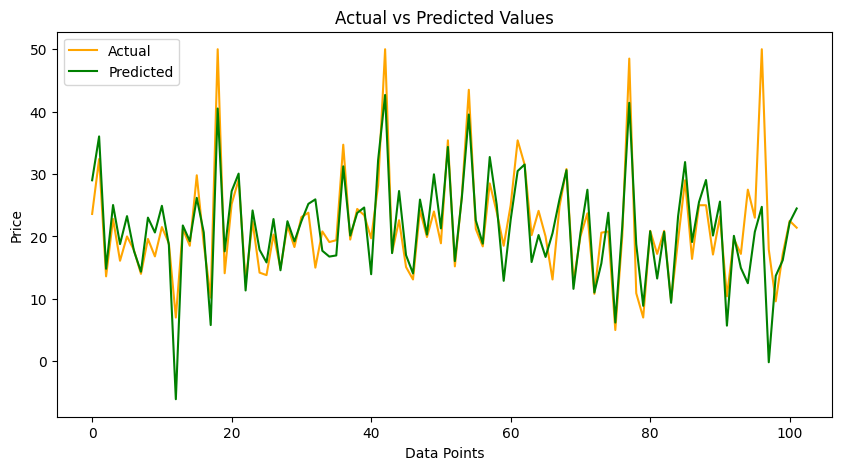

In [56]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values, color='orange', label='Actual')
plt.plot(y_pred, color='green', label='Predicted')

plt.xlabel("Data Points")
plt.ylabel("Price")
plt.title("Actual vs Predicted Values")

plt.legend()
plt.show()